<a href="https://colab.research.google.com/github/muhammedgmbsg/eeg-spectral-attention-cnn/blob/main/A_Hybrid_Approach_Based_on_Spectral_Feature_Imaging_and_CNN_for_Detecting_Student_Confusion_in_Online_Learning_Environments_ipynb_adl%C4%B1_not_defterinin_kopyas%C4%B1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Harika! Gerçek veri seti başarıyla yüklendi.
Veri Boyutu: (12811, 15) (Satır, Sütun)


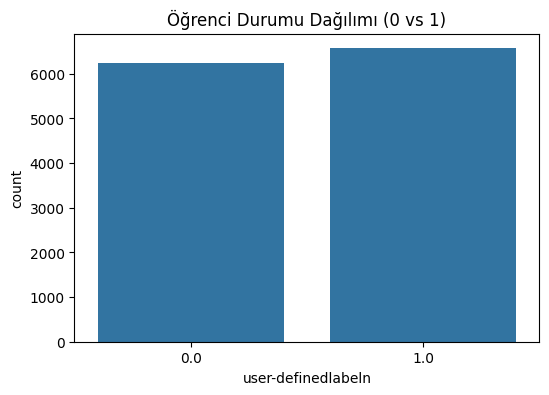

,SubjectID,VideoID,Attention,Mediation,Raw,Delta,Theta,Alpha1,Alpha2,Beta1,Beta2,Gamma1,Gamma2,predefinedlabel,user-definedlabeln
0,0.0,0.0,56.0,43.0,278.0,301963.0,90612.0,33735.0,23991.0,27946.0,45097.0,33228.0,8293.0,0.0,0.0
1,0.0,0.0,40.0,35.0,-50.0,73787.0,28083.0,1439.0,2240.0,2746.0,3687.0,5293.0,2740.0,0.0,0.0
2,0.0,0.0,47.0,48.0,101.0,758353.0,383745.0,201999.0,62107.0,36293.0,130536.0,57243.0,25354.0,0.0,0.0
3,0.0,0.0,47.0,57.0,-5.0,2012240.0,129350.0,61236.0,17084.0,11488.0,62462.0,49960.0,33932.0,0.0,0.0
4,0.0,0.0,44.0,53.0,-8.0,1005145.0,354328.0,37102.0,88881.0,45307.0,99603.0,44790.0,29749.0,0.0,0.0


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Colab'e yüklediğin dosyayı oku
# Dosya isminin tam olarak 'EEG_data.csv' olduğundan emin ol.
filename = 'EEG_data.csv'

try:
    data = pd.read_csv(filename)
    print("✅ Harika! Gerçek veri seti başarıyla yüklendi.")
    print(f"Veri Boyutu: {data.shape} (Satır, Sütun)")

    # 2. Verinin içindeki etiket dağılımına bakalım
    # 0: Anlamadı/Kafası Karıştı, 1: Anladı (veya tam tersi, veri setine göre değişebilir)
    # Genelde bu veri setinde 'user-definedlabeln' hedef değişkendir.
    plt.figure(figsize=(6, 4))
    sns.countplot(x='user-definedlabeln', data=data)
    plt.title('Öğrenci Durumu Dağılımı (0 vs 1)')
    plt.show()

    # 3. İlk 5 satırı görelim
    display(data.head())

except FileNotFoundError:
    print("❌ HATA: Dosya bulunamadı!")
    print("Lütfen sol taraftaki klasör simgesine tıklayıp 'EEG_data.csv' dosyasını yüklediğinden emin ol.")

In [ ]:
import tensorflow as tf
print("GPU Kullanılıyor mu?:", len(tf.config.list_physical_devices('GPU')) > 0)

GPU Kullanılıyor mu?: True


Oluşturulan Toplam Resim Sayısı: 12791
Her Bir Resmin Boyutu: 20 (Zaman) x 8 (Kanal)


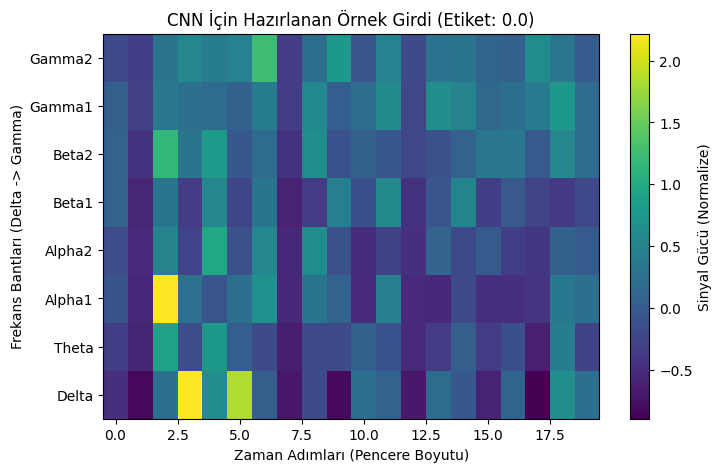

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# 1. Kullanacağımız Beyin Sinyali Sütunlarını Seçelim
# (ID'leri ve etiketleri çıkarıyoruz, sadece saf sinyalleri alıyoruz)
feature_columns = ['Delta', 'Theta', 'Alpha1', 'Alpha2', 'Beta1', 'Beta2', 'Gamma1', 'Gamma2']
X = data[feature_columns].values
y = data['user-definedlabeln'].values # 0: Karışık, 1: Anladı (veya tersi)

# 2. Normalizasyon (Çok Önemli!)
# CNN'ler 0-1 arası veya küçük sayıları sever. Delta 1000 iken Beta 5 ise model şaşırır.
# Hepsini aynı ölçeğe getiriyoruz.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Veriyi Resme Çeviren Fonksiyon (Sliding Window)
def create_images(data, labels, window_size=20):
    images = []
    targets = []

    # Veri setinde adım adım ilerle
    for i in range(len(data) - window_size):
        # 20 satırlık bir kesit al (Bu bizim resmimiz olacak)
        img = data[i:i+window_size]
        images.append(img)

        # Bu pencerenin bittiği andaki etiketi al
        targets.append(labels[i+window_size])

    return np.array(images), np.array(targets)

# 4. Dönüşümü Uygula
# Window Size = 20 (Veri setine göre bu değişebilir, şimdilik 20 satır kullanalım)
X_images, y_labels = create_images(X_scaled, y, window_size=20)

# 5. Sonuçları Kontrol Et
print(f"Oluşturulan Toplam Resim Sayısı: {X_images.shape[0]}")
print(f"Her Bir Resmin Boyutu: {X_images.shape[1]} (Zaman) x {X_images.shape[2]} (Kanal)")

# 6. Örnek Bir "Beyin Resmi" Çizdirelim
plt.figure(figsize=(8, 5))
# Transpose (.T) alıyoruz ki Frekanslar Y ekseninde, Zaman X ekseninde olsun (Daha şık durur)
plt.imshow(X_images[0].T, aspect='auto', cmap='viridis', origin='lower')
plt.colorbar(label='Sinyal Gücü (Normalize)')
plt.title(f'CNN İçin Hazırlanan Örnek Girdi (Etiket: {y_labels[0]})')
plt.xlabel('Zaman Adımları (Pencere Boyutu)')
plt.ylabel('Frekans Bantları (Delta -> Gamma)')
plt.yticks(ticks=np.arange(len(feature_columns)), labels=feature_columns)
plt.show()

Eğitim Verisi: (10232, 20, 8, 1)
Test Verisi: (2559, 20, 8, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 20, 8, 32)      │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 20, 8, 32)      │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 10, 4, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 4, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 10, 4, 64)      │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 640)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 60,289 (235.50 KB)

 Trainable params: 60,097 (234.75 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.5993 - loss: 0.7698 - val_accuracy: 0.6444 - val_loss: 0.6491
Epoch 2/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6727 - loss: 0.6026 - val_accuracy: 0.7108 - val_loss: 0.5582
Epoch 3/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7056 - loss: 0.5458 - val_accuracy: 0.7515 - val_loss: 0.5047
Epoch 4/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7497 - loss: 0.4881 - val_accuracy: 0.7675 - val_loss: 0.4591
Epoch 5/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7837 - loss: 0.4372 - val_accuracy: 0.7980 - val_loss: 0.4302
Epoch 6/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8251 - loss: 0.3673 - val_accuracy: 0.8488 - val_loss: 0.3411
Epoch 7/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8429 - loss: 0.3244 - val_accuracy: 0.8546 - val_loss: 0.3117
Epoch 8/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8723 - loss: 0.2829 - val_accuracy: 0

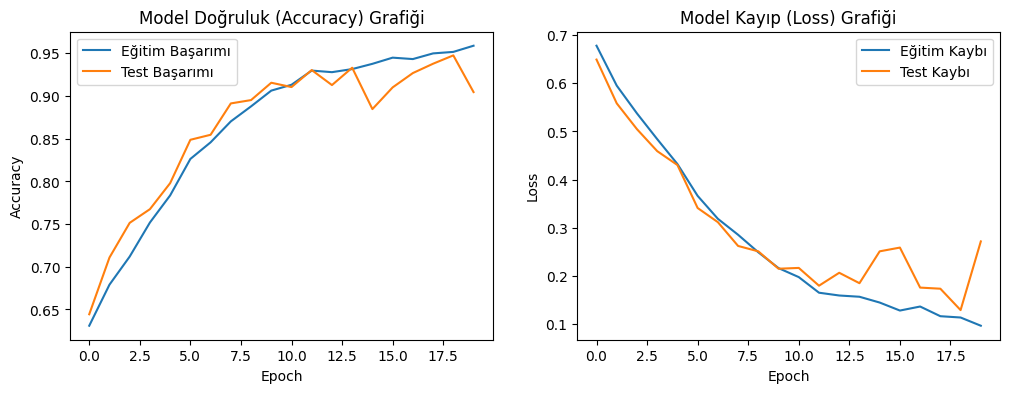

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# 1. Veriyi CNN'e Uygun Hale Getir (Reshape)
# Şu an: (Satır Sayısı, 20, 8) -> Hedef: (Satır Sayısı, 20, 8, 1) -> Sondaki 1, "Gri Tonlamalı" demek.
X_cnn = X_images.reshape(X_images.shape[0], X_images.shape[1], X_images.shape[2], 1)

# 2. Eğitim ve Test Setine Ayır (%80 Eğitim, %20 Test)
X_train, X_test, y_train, y_test = train_test_split(X_cnn, y_labels, test_size=0.2, random_state=42)

print(f"Eğitim Verisi: {X_train.shape}")
print(f"Test Verisi: {X_test.shape}")

# 3. CNN Model Mimarisi (Bildiride "Proposed Architecture" diyeceğimiz kısım)
model = Sequential([
    # -- 1. Evrişim Bloğu --
    Conv2D(32, (3, 3), activation='relu', input_shape=(20, 8, 1), padding='same'),
    BatchNormalization(), # Eğitimi hızlandırır ve stabilize eder
    MaxPooling2D((2, 2)), # Resmin boyutunu yarıya indirir (Önemli özellikleri tutar)

    # -- 2. Evrişim Bloğu --
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # -- Sınıflandırma Bloğu --
    Flatten(), # Resmi düz vektöre çevir
    Dense(64, activation='relu'),
    Dropout(0.5), # Ezberlemeyi (Overfitting) önlemek için nöronların yarısını kapat
    Dense(1, activation='sigmoid') # Çıktı Katmanı: 0 veya 1 (Binary Classification)
])

# Modeli Derle
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Model Özetini Göster
model.summary()

# 4. Eğitimi Başlat (Training)
# Epochs = 20 (Veri setinin üzerinden 20 kere geçecek)
history = model.fit(X_train, y_train,
                    epochs=20,
                    batch_size=32,
                    validation_data=(X_test, y_test),
                    verbose=1)

# 5. Başarım Grafiğini Çiz (Bildiriye Koyacağın Şekil 1)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Eğitim Başarımı')
plt.plot(history.history['val_accuracy'], label='Test Başarımı')
plt.title('Model Doğruluk (Accuracy) Grafiği')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Eğitim Kaybı')
plt.plot(history.history['val_loss'], label='Test Kaybı')
plt.title('Model Kayıp (Loss) Grafiği')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


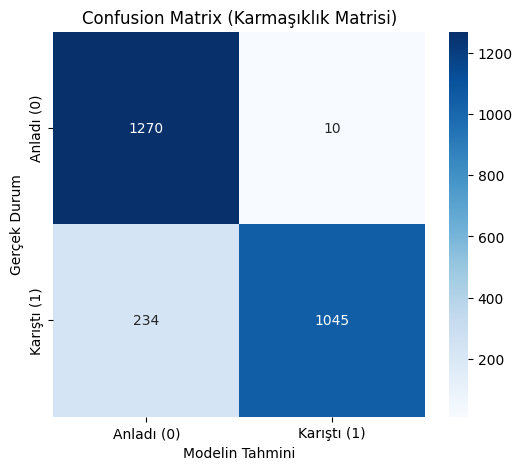


Sınıflandırma Raporu:
              precision    recall  f1-score   support

         0.0       0.84      0.99      0.91      1280
         1.0       0.99      0.82      0.90      1279

    accuracy                           0.90      2559
   macro avg       0.92      0.90      0.90      2559
weighted avg       0.92      0.90      0.90      2559



In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Test verisi üzerinde tahmin yap
y_pred = model.predict(X_test)
# Çıktılar 0.2, 0.9 gibi olasılıklar olduğu için onları 0 veya 1'e yuvarlıyoruz
y_pred_classes = (y_pred > 0.5).astype("int32")

# 2. Matrisi Hesapla
cm = confusion_matrix(y_test, y_pred_classes)

# 3. Şık Bir Grafik Çiz (Bildiri için)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Anladı (0)', 'Karıştı (1)'], yticklabels=['Anladı (0)', 'Karıştı (1)'])
plt.title('Confusion Matrix (Karmaşıklık Matrisi)')
plt.ylabel('Gerçek Durum')
plt.xlabel('Modelin Tahmini')
plt.show()

# 4. Raporu Yazdır
print("\nSınıflandırma Raporu:")
print(classification_report(y_test, y_pred_classes))